In [68]:
import os
import torch
# from tqdm import tqdm
from torch_geometric.data import Data
from torch_geometric.io import fs
from torch_geometric.data import Data, InMemoryDataset
from kipoiseq import Interval

from pyfaidx import Fasta
import torch
import cooler

from graph_data import CreateGraphData

In [2]:
class GraphDataset(InMemoryDataset):
    def __init__(self, root, data_list=None, transform=None, pre_transform=None, pre_filter=None):
        """
        Args:
            root (str): The root directory where the dataset will be stored. 
                        The dataset will be saved in root/raw and root/processed.
            data_list (list): A list containing torch_geometric.data.Data objects.
                              If you already have a list of Data objects, you can pass them directly.
                              If the data needs to be read from files or downloaded, you can leave 
                                  this empty and handle it in download/process.
            transform (callable, optional): A function that is applied to each graph. It is executed before batching in the DataLoader.
            pre_transform (callable, optional): A function that is applied to each graph. It is executed before the data is saved to disk.
            pre_filter (callable, optional): A function used to filter graphs. It is executed before the data is saved to disk.
        """
        self.data_list = data_list
        super().__init__(root, transform, pre_transform, pre_filter)

        out = fs.torch_load(self.processed_paths[0])

        if not isinstance(out, tuple) or len(out) < 3:
            raise RuntimeError(
                "The 'data' object was created by an older version of PyG. "
                "If this error occurred while loading an already existing "
                "dataset, remove the 'processed/' directory in the dataset's "
                "root folder and try again.")
        assert len(out) == 3 or len(out) == 4

        if len(out) == 3:  # Backward compatibility.
            data, self.slices, self.sizes = out
            data_cls = Data
        else:
            data, self.slices, self.sizes, data_cls = out

        if not isinstance(data, dict):  # Backward compatibility.
            self.data = data
        else:
            self.data = data_cls.from_dict(data)
        
    @property
    def raw_file_names(self):
        return [] 

    @property
    def processed_file_names(self):
        return "data.pt"

    def download(self):
        pass
        
    def process(self):
        if self.data_list is None:
            raise RuntimeError("data_list not provided. In a real scenario, you'd load from raw files here.")

        data_list = self.data_list

        if self.pre_filter is not None:
            data_list = [d for d in data_list if self.pre_filter(d)]

        if self.pre_transform is not None:
            data_list = [self.pre_transform(d) for d in data_list]

        self.data, self.slices = self.collate(data_list)             
        self._data_list = None

        assert isinstance(self._data, Data)
        fs.torch_save(
            (self._data.to_dict(), self.slices, len(self.data_list), self._data.__class__),
            self.processed_paths[0],
        )

In [3]:
# class EpiConcatMatrix(object):
    

In [4]:
clr = cooler.Cooler("./develop_test/wt_hic_4096.cool")

In [5]:
2 ** 20 / 4096

256.0

In [6]:
from data import FastaInterval

In [7]:
fasta = FastaInterval("./data/hg38.fa")

In [8]:
interval = Interval('chr1', 59000000, 59000000 + 2**20)

In [9]:
fasta.extract(interval=interval)

array([[0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.],
       ...,
       [1., 0., 0., 0.],
       [0., 0., 0., 1.],
       [1., 0., 0., 0.]], shape=(1048576, 4), dtype=float32)

In [10]:
59000000 + 2 ^ 20

59000022

In [11]:
from finetune_enformer import EnformerFineTunerPL

In [12]:
pl_model = EnformerFineTunerPL.load_from_checkpoint("./checkpoints/enformer-finetuned-epoch=09-val_loss_epoch=-0.1210.ckpt")
device = pl_model.device

/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:209: Attribute 'enformer_model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['enformer_model'])`.


In [13]:
device

device(type='cuda', index=1)

In [14]:
# output = pl_model(torch.tensor(fasta.extract(interval=interval)).to(device))

In [15]:
# torch.concat([output.t().cpu(), output.t().cpu()], dim=1).shape

In [16]:
# torch.concat?

In [17]:
len(interval)

1048576

In [18]:
clr.matrix(balance=True).fetch(f"{str(interval)[:-2]}").dtype

dtype('float64')

In [71]:
from graph_data import EpiConcatMatrix

In [19]:
# testing = EpiConcatMatrix(fasta_file="./data/hg38.fa", 
#                           cool_file="./develop_test/wt_hic_4096.cool", 
#                           model=pl_model, region_length="4M")

In [20]:
# interval = Interval('chr1', 59000000, 59000000 + 2**22)
# x, y = testing(interval)

In [21]:
2 ** 20 / 4096

256.0

In [22]:
interval = Interval('chr1', 59000000 + 0, 59000000 + 2**20)
clr.matrix(balance=True).fetch(f"{str(interval)[:-2]}").shape

(257, 257)

In [23]:
# traning data
train_chr = ['chr3', 'chr4', 'chr5', 'chr6', 'chr7',
            'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17',
            'chr19', 'chr21', 'chr22', 'chrX']


# validation data

validation_chr = ['chr2', 'chr18', 'chr20']

# test data

test_chr = ['chr1', 'chr8']

In [60]:
# 生成训练，验证和测试数据集合的区间文件

def create_genome_tiles(chroms, output_bed, window_size=2 ** 21, stride= 2 ** 21 // 8, fasta_file="./data/hg38.fa"):
    fasta = Fasta(fasta_file)
    
    if isinstance(chroms, str):
        chroms = [chroms]

    with open(output_bed, 'w') as f_out:
        for chrom in chroms:
            length = len(fasta[chrom])
            # print(f"{chrom} {length}")

            for start in range(100 + 320 * 128, length-window_size-(196608-320*128), stride):
                end = start + window_size
                f_out.write(f"{chrom}\t{start}\t{end}\n")

# 训练数据
create_genome_tiles(chroms=train_chr, output_bed="./develop_test/train_3d_region.bed")

# 验证数据
create_genome_tiles(chroms=validation_chr, output_bed="./develop_test/validation_3d_region.bed")

# 测试数据集合
create_genome_tiles(chroms=test_chr, output_bed="./develop_test/test_3d_region.bed")

In [24]:
data = CreateGraphData(
    interval_file="./develop_test/train_3d_region.bed", 
    fasta_file="./data/hg38.fa",
    cool_file="./develop_test/wt_hic_4096.cool",
    region_length="2M", model=pl_model
)

In [25]:
data.extract_data(Interval("chr20", 50634852, 52732004))

Data(x=[512, 160], edge_index=[2, 48650], target=[512, 512], region='chr20:50634852-52732004:.')

In [26]:
def create_neighbor_graph(num_nodes: int, num_neighbors: int) -> torch.Tensor:
    edge_j = torch.repeat_interleave(torch.arange(num_nodes-1, dtype=torch.long), num_neighbors)

    edge_i = torch.tensor([j for i in range(1, num_nodes) for j in range(i, i+ num_neighbors)], dtype=torch.long)
    edge_index = torch.stack([edge_i, edge_j], dim=0)
    edge_index = edge_index[:, :-(num_neighbors - 1)]

    edge_index = torch.cat([edge_index, torch.flip(edge_index, dims=[0])], dim=1)

    return edge_index

In [78]:
# create_neighbor_graph(1000, 50)[:, -100:]

In [69]:
dataset = GraphDataset(root="./develop_test/graph_data_4096_2M")

In [70]:
dataset[1].x

tensor([[0.0225, 0.0252, 0.0232,  ..., 0.0896, 0.0552, 0.1222],
        [0.0308, 0.0314, 0.0299,  ..., 0.0992, 0.0787, 0.1196],
        [0.0209, 0.0211, 0.0314,  ..., 0.2679, 0.7273, 0.4023],
        ...,
        [0.0298, 0.0253, 0.0244,  ..., 0.0510, 0.0611, 0.1214],
        [0.0269, 0.0273, 0.0260,  ..., 0.1380, 0.1438, 0.1856],
        [0.0231, 0.0209, 0.0209,  ..., 0.0678, 0.0891, 0.0408]],
       device='cuda:1')

In [29]:
len(dataset)

8433

In [30]:
dataset[0]

Data(x=[512, 160], edge_index=[2, 51002], target=[512, 512], region='chr3	41060	2138212
')

In [31]:
dataset[1].target.shape

torch.Size([512, 512])

'chr3\t303204\t2400356\n'

In [93]:
print("hello worl")

hello worl


In [107]:
f = torch.nn.Softplus()
f(torch.tensor([0.001], dtype=torch.float32))

tensor([0.6936])

In [32]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap


colors = [
    (0.0, '#FFFFFF'),    # 白色 (White) - 最低值
    (0.001, '#FFEEEE'),  # 极其浅的红色 - 接近白色，用于显示微弱接触
    (0.05, '#FFBBBB'),   # 较浅的红色
    (0.2, '#FF8888'),    # 中等红色
    (0.5, '#FF4444'),    # 较深的红色
    (1.0, '#FF0000')     # 饱和红色 (Pure Red) - 最高值
]

custom_cmap = LinearSegmentedColormap.from_list("white_to_red_hic", colors)

/tmp/ipykernel_3639/2240179740.py:17: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

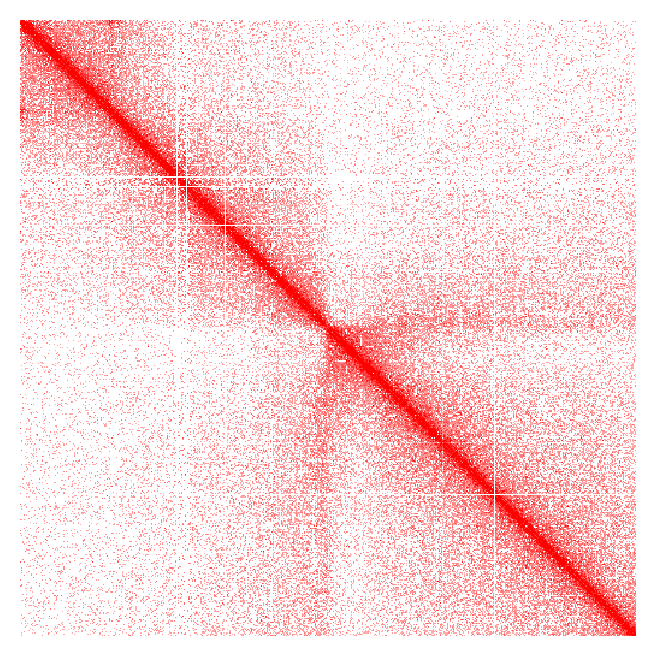

In [33]:
# f, axs = plt.subplots(figsize=(14,11), ncols=3, nrows=2)

# for idx in range(6):
#     ax = axs[idx // 3, idx % 3]

#     interval_each = interval.resize(2 ** idx * 1000000)
#     im = ax.matshow(cls_8192.matrix(balance=True).fetch(f"{str(interval_each)[:-2]}"), 
#                     vmax=0.009, cmap=custom_cmap)
#     ax.set_title(f"{2 ** idx} M \n {str(interval_each)[:-2]}")
#     ax.axis('off')
    
#     # plt.colorbar(im, ax=ax ,fraction=0.046, pad=0.04, label='ICE');
# plt.tight_layout() 


from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

matrix = dataset[0].target.detach().cpu().numpy()

matrix = matrix * 100
matrix[matrix >1] = 1

f, ax = plt.subplots(figsize=(4, 4), ncols=1, nrows=1)
im = ax.matshow(matrix, cmap=custom_cmap, vmax=1)
ax.axis('off')



In [34]:
dataset[4000]

Data(x=[512, 160], edge_index=[2, 51002], target=[512, 512], region='chr10	23109732	25206884
')

In [35]:
4096 / 128

32.0

In [36]:
2000000 / 196608

10.172526041666666

In [37]:
from torch_geometric.data import DataLoader

In [38]:
dataloader = DataLoader(dataset, batch_size=4)

/public/home/zju12218076/miniconda3/envs/project/lib/python3.10/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [39]:
for batch in dataloader:
    break

In [40]:
batch[0], batch[1]

(Data(x=[512, 160], edge_index=[2, 51002], target=[512, 512], region='chr3	41060	2138212
 '),
 Data(x=[512, 160], edge_index=[2, 51002], target=[512, 512], region='chr3	303204	2400356
 '))

In [71]:
from model import DNA3D_GAT

In [72]:
model_d = DNA3D_GAT(num_bins=512, in_feats=160, bin_size=5096, max_distance=2**21, hidden_dim=320)

In [73]:
dataset[0].x.device

device(type='cuda', index=1)

In [74]:
model_d = model_d.to("cuda:1")

In [75]:
# model_d(dataset[0])

In [76]:
import graph_data

In [77]:
def create_neighbor_graph_simplified(num_nodes: int, num_neighbors: int) -> torch.Tensor:
    # num_neighbors is half-bandwidth, meaning nodes are connected if their distance is <= num_neighbors
    # Let's consider `num_neighbors` as the maximum distance in bins.
    
    # Upper triangular part
    rows_upper = []
    cols_upper = []
    for k in range(1, num_neighbors + 1): # k is the genomic distance in bins
        # Connect i to i+k
        rows_upper.append(torch.arange(0, num_nodes - k, dtype=torch.long))
        cols_upper.append(torch.arange(k, num_nodes, dtype=torch.long))

    if not rows_upper: # Handle case where num_nodes is too small for any neighbors
        return torch.empty((2, 0), dtype=torch.long)

    edge_i_upper = torch.cat(rows_upper)
    edge_j_upper = torch.cat(cols_upper)

    # Concatenate and add symmetric edges
    edge_index = torch.stack([
        torch.cat([edge_i_upper, edge_j_upper]),
        torch.cat([edge_j_upper, edge_i_upper])
    ], dim=0)

    # Remove self-loops (if k=0 was included or for other reasons, not here)
    # edge_index = edge_index[:, edge_index[0] != edge_index[1]]

    return edge_index

In [60]:
index.max()

tensor(511)

In [78]:
index = create_neighbor_graph_simplified(512, 1)
dataset[0].edge_index = index

data = Data(x = dataset[0].x, edge_index=index)

data = data.to("cuda:1")

In [79]:
model_d(data)

tensor([0.0024, 0.0024, 0.0024,  ..., 0.0024, 0.0024, 0.0024], device='cuda:1')


tensor([[0.0000, 0.1561, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.1561, 0.0000, 0.2720,  ..., 0.0000, 0.0000, 0.0000],
        [0.0000, 0.2720, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.1467, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.1467, 0.0000, 0.3309],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.3309, 0.0000]],
       device='cuda:1', grad_fn=<DivBackward0>)

In [80]:
model_d.compute_loss(data, target=dataset[0].target)

tensor([0.0024, 0.0024, 0.0024,  ..., 0.0024, 0.0024, 0.0024], device='cuda:1')


tensor(0.0006, device='cuda:1', grad_fn=<AddBackward0>)

In [82]:
from torch.optim import AdamW

# optimazr = AdamW()

In [85]:
model_d = DNA3D_GAT(num_bins=512, in_feats=160, bin_size=5096, max_distance=2**21, hidden_dim=320)

optimazer = AdamW(model_d.parameters(), lr=0.0001)

In [86]:
model_d = model_d.to(data.x.device)
for idx in range(10):
    optimazer.zero_grad()

    loss = model_d.compute_loss(data, target=dataset[0].target)
    loss.backward()

    optimazer.step()

    if idx % 100 == 0:
        print(f"{idx} {loss}")

    

tensor([0.0024, 0.0024, 0.0024,  ..., 0.0024, 0.0024, 0.0024], device='cuda:1')
0 0.005272200331091881
tensor([0.0024, 0.0024, 0.0024,  ..., 0.0024, 0.0024, 0.0024], device='cuda:1')
tensor([0.0024, 0.0024, 0.0024,  ..., 0.0024, 0.0024, 0.0024], device='cuda:1')
tensor([0.0024, 0.0024, 0.0024,  ..., 0.0024, 0.0024, 0.0024], device='cuda:1')
tensor([0.0024, 0.0024, 0.0024,  ..., 0.0024, 0.0024, 0.0024], device='cuda:1')
tensor([0.0024, 0.0024, 0.0024,  ..., 0.0024, 0.0024, 0.0024], device='cuda:1')
tensor([0.0024, 0.0024, 0.0024,  ..., 0.0024, 0.0024, 0.0024], device='cuda:1')
tensor([0.0024, 0.0024, 0.0024,  ..., 0.0024, 0.0024, 0.0024], device='cuda:1')
tensor([0.0024, 0.0024, 0.0024,  ..., 0.0024, 0.0024, 0.0024], device='cuda:1')
tensor([0.0024, 0.0024, 0.0024,  ..., 0.0024, 0.0024, 0.0024], device='cuda:1')


tensor([0.0024, 0.0024, 0.0024,  ..., 0.0024, 0.0024, 0.0024], device='cuda:1')


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

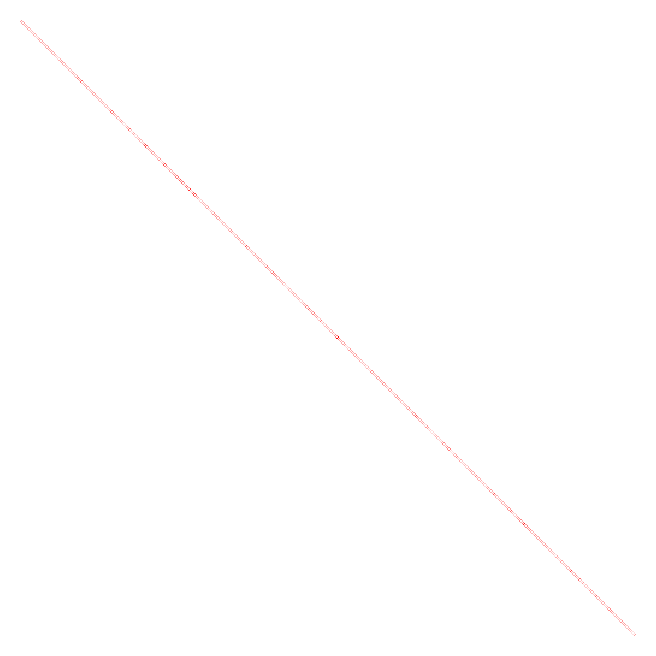

In [87]:
matrix = model_d(data).detach().cpu().numpy()

# matrix = matrix * 100
# matrix[matrix >1] = 1

f, ax = plt.subplots(figsize=(4, 4), ncols=1, nrows=1)
im = ax.matshow(matrix, cmap=custom_cmap)
ax.axis('off')

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

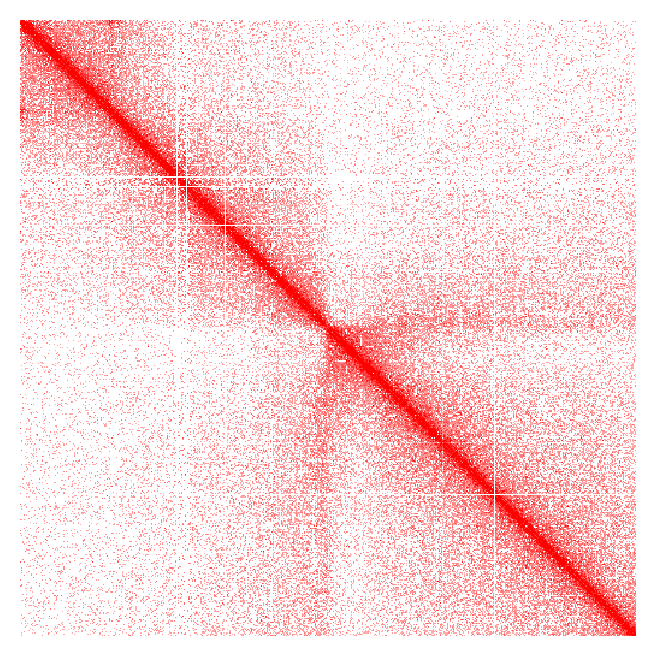

In [254]:
matrix = dataset[0].target.detach().cpu().numpy()

matrix = matrix * 100
matrix[matrix >1] = 1

f, ax = plt.subplots(figsize=(4, 4), ncols=1, nrows=1)
im = ax.matshow(matrix, cmap=custom_cmap, vmax=1)
ax.axis('off')

In [65]:
from .model import DNA3DIntteractionModel

ImportError: attempted relative import with no known parent package